## Exploratory data analysis

This notebook performs EDA on the DDR step chart dataset, comparing human-authored charts with AI-generated charts from the Dance Dance Convolution model.

### Dataset overview
- **Human charts**: `data/real/{fraxtil,itg}/*_human.json`
- **AI charts**: `data/artificial/{fraxtil,itg}/*_ai.json`

### Step notation
Each step is a 4-character string representing the state of each arrow:
- Position: `[Left, Down, Up, Right]`
- Values: `0` = off, `1` = tap, `2` = hold start, `3` = hold end

In [24]:
import json
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

PROJECT_ROOT = Path('..').resolve()
REAL_DIR = PROJECT_ROOT / 'data' / 'real'
ARTIFICIAL_DIR = PROJECT_ROOT / 'data' / 'artificial'
DATASETS = ['fraxtil', 'itg']
DIFFICULTIES = ['Beginner', 'Easy', 'Medium', 'Hard', 'Challenge']

### 1. Load all charts

In [25]:
def load_charts(base_dir: Path, suffix: str) -> list[dict]:
    charts = []
    for dataset in DATASETS:
        dataset_dir = base_dir / dataset
        if not dataset_dir.exists():
            continue
        for json_path in dataset_dir.glob(f'*{suffix}.json'):
            with open(json_path, 'r') as f:
                data = json.load(f)
            song_name = data.get('song_name', json_path.stem)
            for diff_name, chart_data in data.get('charts', {}).items():
                steps = chart_data.get('steps', [])
                charts.append({
                    'song_name': song_name,
                    'dataset': dataset,
                    'difficulty': diff_name,
                    'num_steps': len(steps),
                    'steps': steps,
                    'source': 'human' if suffix == '_human' else 'ai'
                })
    return charts

human_charts = load_charts(REAL_DIR, '_human')
ai_charts = load_charts(ARTIFICIAL_DIR, '_ai')

print(f"Human charts: {len(human_charts)}")
print(f"AI charts: {len(ai_charts)}")
print(f"Total: {len(human_charts) + len(ai_charts)}")

Human charts: 1094
AI charts: 1109
Total: 2203


### 2. Data validation

In [26]:
def validate_chart(chart: dict) -> dict:
    issues = []
    steps = chart['steps']
    
    if not steps:
        issues.append("Empty chart")
        return {'valid': False, 'issues': issues}
    
    has_time = all('time' in s for s in steps)
    if not has_time:
        issues.append("Missing 'time' field in some steps")
    
    has_step = all('step' in s for s in steps)
    if not has_step:
        issues.append("Missing 'step' field in some steps")
    
    if has_step:
        valid_steps = all(
            len(s['step']) == 4 and all(c in '0123' for c in s['step'])
            for s in steps
        )
        if not valid_steps:
            issues.append("Invalid step format (should be 4 chars of 0-3)")
    
    if has_time and len(steps) > 1:
        times = [s['time'] for s in steps]
        if times != sorted(times):
            issues.append("Steps not sorted by time")
        if any(t < 0 for t in times):
            issues.append("Negative time values")
    
    return {'valid': len(issues) == 0, 'issues': issues}

all_charts = human_charts + ai_charts
validation_results = [validate_chart(c) for c in all_charts]
valid_count = sum(1 for v in validation_results if v['valid'])
invalid_count = len(validation_results) - valid_count

print(f"Valid charts: {valid_count}/{len(all_charts)}")
print(f"Invalid charts: {invalid_count}")

if invalid_count > 0:
    print("\nSample issues:")
    for i, (chart, result) in enumerate(zip(all_charts, validation_results)):
        if not result['valid']:
            print(f"  {chart['song_name']} ({chart['source']}, {chart['difficulty']}): {result['issues']}")
            if i > 5:
                break

Valid charts: 2203/2203
Invalid charts: 0


### 3. Dataset statistics

In [27]:
def extract_features(chart: dict) -> dict:
    steps = chart['steps']
    if not steps:
        return None
    
    times = [s['time'] for s in steps]
    step_patterns = [s['step'] for s in steps]
    
    delta_times = np.diff(times) if len(times) > 1 else np.array([0])
    
    single_arrows = sum(1 for s in step_patterns if s.count('0') == 3 and '2' not in s and '3' not in s)
    jumps = sum(1 for s in step_patterns if s.count('1') == 2)
    holds = sum(1 for s in step_patterns if '2' in s)
    releases = sum(1 for s in step_patterns if '3' in s)
    
    arrow_counts = [0, 0, 0, 0]
    for step in step_patterns:
        for i, char in enumerate(step):
            if char in '123':
                arrow_counts[i] += 1
    total_arrows = sum(arrow_counts) or 1
    
    duration = max(times) - min(times) if times else 0
    
    return {
        'song_name': chart['song_name'],
        'dataset': chart['dataset'],
        'difficulty': chart['difficulty'],
        'source': chart['source'],
        'num_steps': len(steps),
        'duration': duration,
        'steps_per_second': len(steps) / duration if duration > 0 else 0,
        'mean_delta': np.mean(delta_times),
        'std_delta': np.std(delta_times),
        'min_delta': np.min(delta_times),
        'max_delta': np.max(delta_times),
        'single_arrow_ratio': single_arrows / len(steps),
        'jump_ratio': jumps / len(steps),
        'hold_ratio': holds / len(steps),
        'left_ratio': arrow_counts[0] / total_arrows,
        'down_ratio': arrow_counts[1] / total_arrows,
        'up_ratio': arrow_counts[2] / total_arrows,
        'right_ratio': arrow_counts[3] / total_arrows,
        'unique_patterns': len(set(step_patterns)),
    }

features = [extract_features(c) for c in all_charts]
features = [f for f in features if f is not None]
df = pd.DataFrame(features)

print(f"DataFrame shape: {df.shape}")
df.head(10)

DataFrame shape: (2203, 19)


,song_name,dataset,difficulty,source,num_steps,duration,steps_per_second,mean_delta,std_delta,min_delta,max_delta,single_arrow_ratio,jump_ratio,hold_ratio,left_ratio,down_ratio,up_ratio,right_ratio,unique_patterns
0,Mosh Pit,fraxtil,Challenge,human,663,113.590909,5.836735,0.171587,0.108981,0.068182,0.818182,0.723982,0.049774,0.113122,0.230028,0.269972,0.260331,0.239669,32
1,Mosh Pit,fraxtil,Hard,human,485,113.045455,4.290310,0.233565,0.102429,0.136364,0.818182,0.742268,0.167010,0.045361,0.252613,0.245645,0.252613,0.249129,24
2,Mosh Pit,fraxtil,Medium,human,356,113.454545,3.137821,0.319590,0.106877,0.272727,0.818182,0.918539,0.070225,0.005618,0.231169,0.267532,0.270130,0.231169,12
3,Mosh Pit,fraxtil,Easy,human,168,113.454545,1.480769,0.679369,0.236647,0.272727,1.090909,0.863095,0.017857,0.059524,0.211111,0.294444,0.288889,0.205556,17
4,Mosh Pit,fraxtil,Beginner,human,99,113.454545,0.872596,1.157699,0.375850,0.545455,2.181818,0.989899,0.010101,0.000000,0.240000,0.260000,0.260000,0.240000,5
5,Turn Up (The Music),fraxtil,Challenge,human,1389,164.485714,8.444502,0.118506,0.098255,0.042857,1.028571,0.924406,0.039597,0.017999,0.247580,0.252420,0.251037,0.248963,20
6,Turn Up (The Music),fraxtil,Hard,human,1115,164.485714,6.778704,0.147653,0.118280,0.042857,1.028571,0.879821,0.056502,0.034081,0.251684,0.251684,0.254209,0.242424,28
7,Turn Up (The Music),fraxtil,Medium,human,643,164.400000,3.911192,0.256075,0.168326,0.085714,1.028571,0.359253,0.139969,0.258165,0.258883,0.255076,0.239848,0.246193,39
8,Turn Up (The Music),fraxtil,Easy,human,295,164.057143,1.798154,0.558017,0.245686,0.342857,2.400000,0.979661,0.000000,0.010169,0.227119,0.277966,0.277966,0.216949,8
9,Turn Up (The Music),fraxtil,Beginner,human,92,163.200000,0.563725,1.793407,0.616424,1.371429,3.085714,0.913043,0.086957,0.000000,0.240000,0.250000,0.260000,0.250000,6


In [28]:
from IPython.display import display

diff_order = ['Beginner', 'Easy', 'Medium', 'Hard', 'Challenge']
df['difficulty'] = pd.Categorical(df['difficulty'], categories=diff_order, ordered=True)

print("By Source:")
display(df.groupby('source')[['num_steps', 'steps_per_second', 'unique_patterns']].mean().round(2))

print("\nBy Dataset:")
display(df.groupby('dataset')[['num_steps', 'steps_per_second', 'unique_patterns']].mean().round(2))

print("\nBy Difficulty:")
display(df.groupby('difficulty', observed=True)[['num_steps', 'steps_per_second', 'unique_patterns']].mean().round(2))

By Source:


,num_steps,steps_per_second,unique_patterns
source,,,
ai,410.09,3.5,24.18
human,317.79,2.8,18.94



By Dataset:


,num_steps,steps_per_second,unique_patterns
dataset,,,
fraxtil,406.15,3.22,23.10
itg,335.91,3.10,20.54



By Difficulty:


,num_steps,steps_per_second,unique_patterns
difficulty,,,
Beginner,105.74,0.95,8.96
Easy,221.76,1.95,16.60
Medium,325.71,2.84,22.89
Hard,488.18,4.21,28.09
Challenge,691.07,5.90,31.67


### 4. Visualizations

#### 4.1 Step count distribution

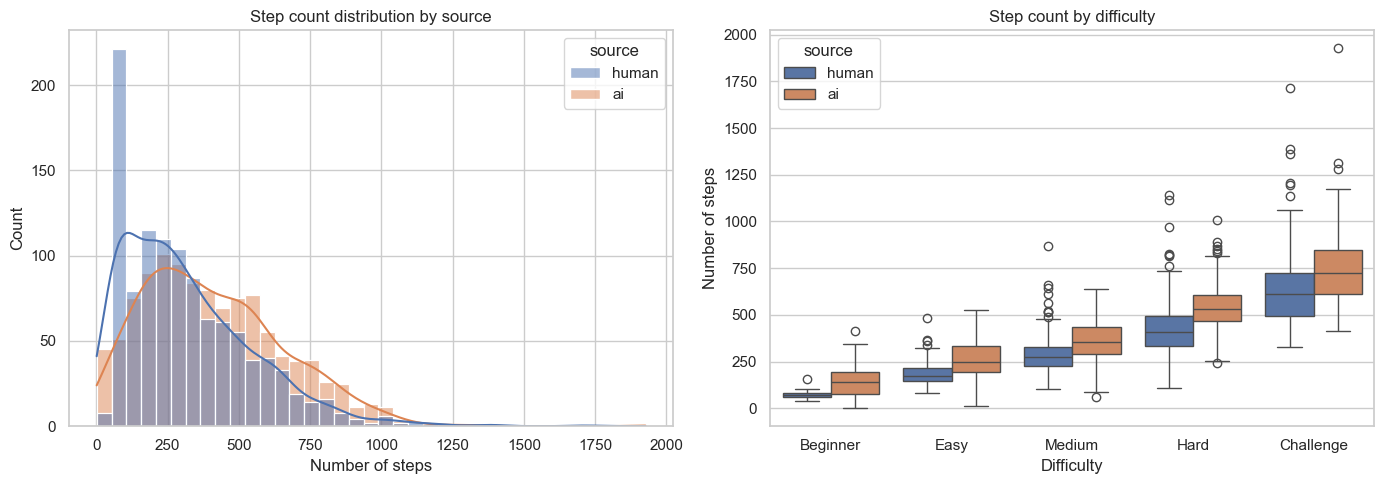

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='num_steps', hue='source', kde=True, ax=axes[0])
axes[0].set_title('Step count distribution by source')
axes[0].set_xlabel('Number of steps')

sns.boxplot(data=df, x='difficulty', y='num_steps', hue='source', ax=axes[1])
axes[1].set_title('Step count by difficulty')
axes[1].set_xlabel('Difficulty')
axes[1].set_ylabel('Number of steps')

plt.tight_layout()
plt.show()

### 4.2 Step density (steps per pecond)

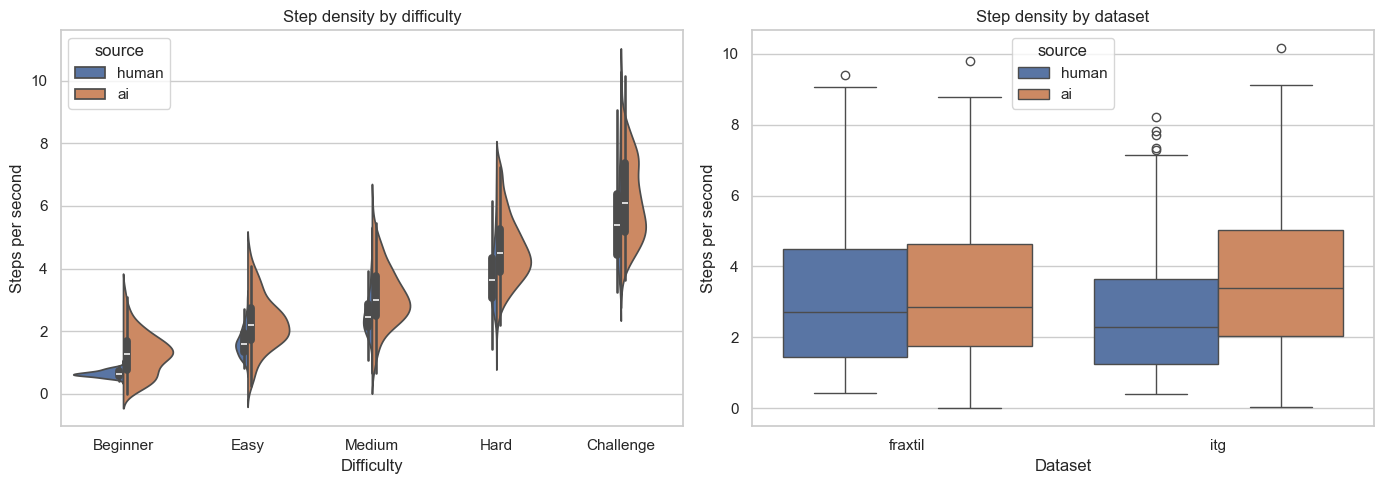

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=df, x='difficulty', y='steps_per_second', hue='source', split=True, ax=axes[0])
axes[0].set_title('Step density by difficulty')
axes[0].set_xlabel('Difficulty')
axes[0].set_ylabel('Steps per second')

sns.boxplot(data=df, x='dataset', y='steps_per_second', hue='source', ax=axes[1])
axes[1].set_title('Step density by dataset')
axes[1].set_xlabel('Dataset')
axes[1].set_ylabel('Steps per second')

plt.tight_layout()
plt.show()

### 4.3 Step pattern composition

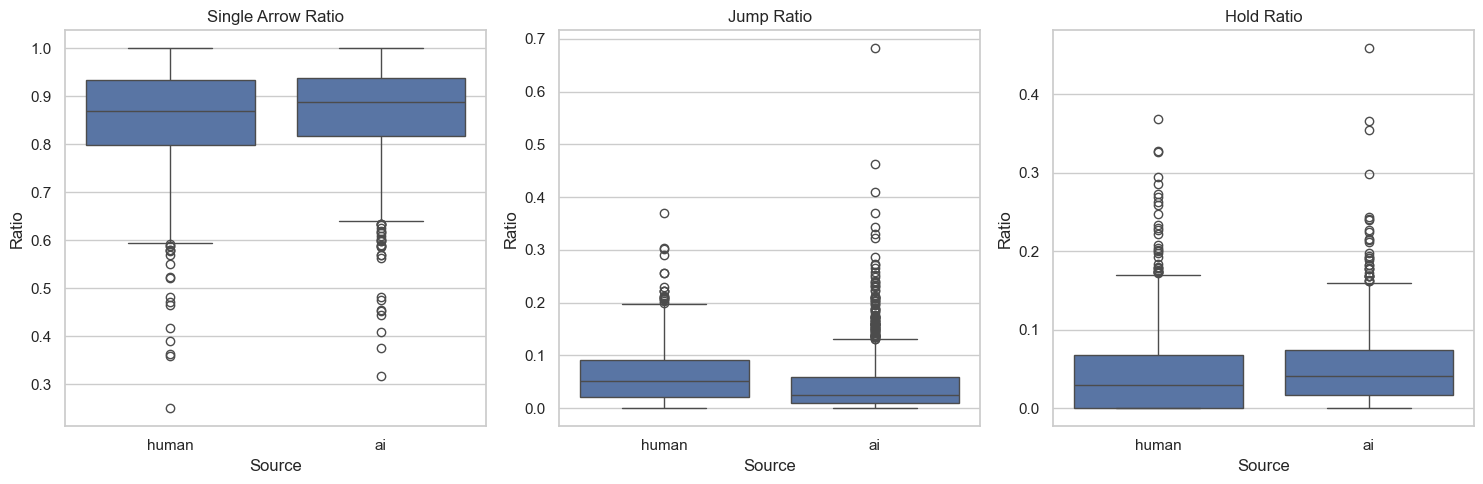

Mean ratios by source:


,single_arrow_ratio,jump_ratio,hold_ratio
source,,,
ai,0.867,0.046,0.052
human,0.858,0.062,0.044


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (col, title) in zip(axes, [
    ('single_arrow_ratio', 'Single Arrow Ratio'),
    ('jump_ratio', 'Jump Ratio'),
    ('hold_ratio', 'Hold Ratio')
]):
    sns.boxplot(data=df, x='source', y=col, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Source')
    ax.set_ylabel('Ratio')

plt.tight_layout()
plt.show()

print("Mean ratios by source:")
df.groupby('source')[['single_arrow_ratio', 'jump_ratio', 'hold_ratio']].mean().round(3)

### 4.4 Arrow distribution

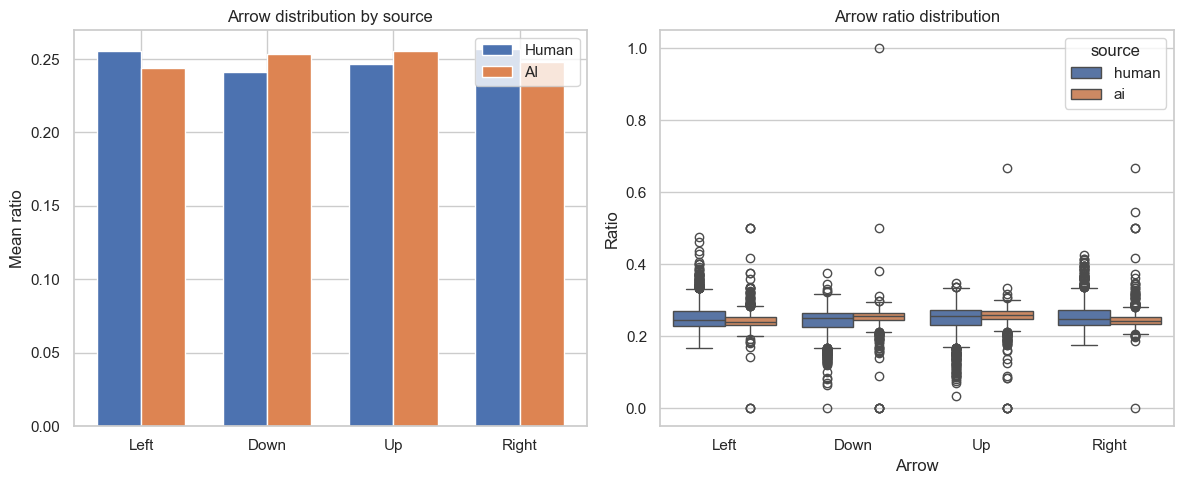

In [32]:
arrow_cols = ['left_ratio', 'down_ratio', 'up_ratio', 'right_ratio']
arrow_names = ['Left', 'Down', 'Up', 'Right']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

human_arrows = df[df['source'] == 'human'][arrow_cols].mean()
ai_arrows = df[df['source'] == 'ai'][arrow_cols].mean()

x = np.arange(len(arrow_names))
width = 0.35

axes[0].bar(x - width/2, human_arrows, width, label='Human')
axes[0].bar(x + width/2, ai_arrows, width, label='AI')
axes[0].set_ylabel('Mean ratio')
axes[0].set_title('Arrow distribution by source')
axes[0].set_xticks(x)
axes[0].set_xticklabels(arrow_names)
axes[0].legend()

arrow_data = df.melt(id_vars=['source'], value_vars=arrow_cols, var_name='arrow', value_name='ratio')
arrow_data['arrow'] = arrow_data['arrow'].str.replace('_ratio', '').str.title()
sns.boxplot(data=arrow_data, x='arrow', y='ratio', hue='source', ax=axes[1])
axes[1].set_title('Arrow ratio distribution')
axes[1].set_xlabel('Arrow')
axes[1].set_ylabel('Ratio')

plt.tight_layout()
plt.show()


### 5. Step pattern analysis

In [33]:
human_patterns = Counter()
ai_patterns = Counter()

for chart in all_charts:
    patterns = [s['step'] for s in chart['steps']]
    if chart['source'] == 'human':
        human_patterns.update(patterns)
    else:
        ai_patterns.update(patterns)

print(f"Unique patterns - Human: {len(human_patterns)}, AI: {len(ai_patterns)}, Shared: {len(set(human_patterns.keys()) & set(ai_patterns.keys()))}")
top_human = human_patterns.most_common(10)
top_ai = ai_patterns.most_common(10)

pd.DataFrame({
    'Human Pattern': [p for p, _ in top_human],
    'Human Count': [c for _, c in top_human],
    'AI Pattern': [p for p, _ in top_ai],
    'AI Count': [c for _, c in top_ai],
})

Unique patterns - Human: 94, AI: 130, Shared: 78


,Human Pattern,Human Count,AI Pattern,AI Count
0,0010,77412,0010,103588
1,0100,75292,0100,101232
2,0001,70092,0001,96267
3,1000,69478,1000,94538
4,1001,6668,1001,4969
5,0110,3803,0200,4387
6,0020,3441,0020,4078
7,0200,3326,0110,3522
8,0002,3177,2000,3295
9,2000,3167,0002,3283


### 5.1 N-gram analysis

In [34]:
def get_ngrams(chart: dict, n: int = 2) -> list[tuple]:
    patterns = [s['step'] for s in chart['steps']]
    if len(patterns) < n:
        return []
    return [tuple(patterns[i:i+n]) for i in range(len(patterns) - n + 1)]

human_bigrams = Counter()
ai_bigrams = Counter()

for chart in all_charts:
    bigrams = get_ngrams(chart, n=2)
    if chart['source'] == 'human':
        human_bigrams.update(bigrams)
    else:
        ai_bigrams.update(bigrams)

top_human_bg = human_bigrams.most_common(10)
top_ai_bg = ai_bigrams.most_common(10)

pd.DataFrame({
    'Human transition': [f"{b[0]} -> {b[1]}" for b, _ in top_human_bg],
    'Human count': [c for _, c in top_human_bg],
    'AI transition': [f"{b[0]} -> {b[1]}" for b, _ in top_ai_bg],
    'AI count': [c for _, c in top_ai_bg],
})

,Human transition,Human count,AI transition,AI count
0,0010 -> 0100,29511,0010 -> 0100,43069
1,0100 -> 0010,29333,0100 -> 0010,42244
2,1000 -> 0001,22418,0001 -> 1000,34023
3,0001 -> 1000,22328,1000 -> 0001,33931
4,0001 -> 0010,18504,0001 -> 0010,26416
5,1000 -> 0010,17820,1000 -> 0010,25508
6,0010 -> 1000,17770,0010 -> 0001,25127
7,0010 -> 0001,17235,0100 -> 0001,25017
8,0001 -> 0100,17205,0001 -> 0100,24908
9,1000 -> 0100,17172,1000 -> 0100,24472


### 6. Matched pairs comparison

Compare human vs. AI charts for the same song and difficulty.

In [35]:
human_index = {(c['song_name'], c['difficulty']): c for c in human_charts}
ai_index = {(c['song_name'], c['difficulty']): c for c in ai_charts}

matched_keys = set(human_index.keys()) & set(ai_index.keys())
print(f"Matched pairs (same song + difficulty): {len(matched_keys)}")

matched_df = df[df.apply(lambda x: (x['song_name'], x['difficulty']) in matched_keys, axis=1)]
print(f"Charts in matched pairs: {len(matched_df)}")

Matched pairs (same song + difficulty): 1093
Charts in matched pairs: 2186


Step count comparison (AI vs. human):
  Mean difference: 89.6
  Median difference: 87.0
  Mean ratio (AI/human): 1.49


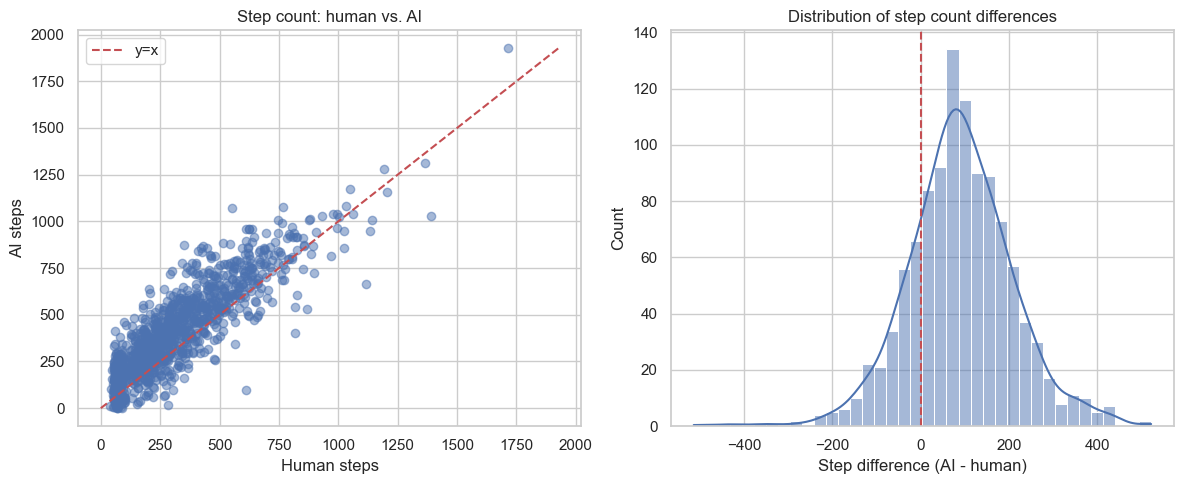

In [36]:
comparison_data = []

for key in matched_keys:
    human = human_index[key]
    ai = ai_index[key]
    
    human_steps = len(human['steps'])
    ai_steps = len(ai['steps'])
    
    comparison_data.append({
        'song_name': key[0],
        'difficulty': key[1],
        'human_steps': human_steps,
        'ai_steps': ai_steps,
        'step_diff': ai_steps - human_steps,
        'step_ratio': ai_steps / human_steps if human_steps > 0 else 0
    })

comparison_df = pd.DataFrame(comparison_data)

print("Step count comparison (AI vs. human):")
print(f"  Mean difference: {comparison_df['step_diff'].mean():.1f}")
print(f"  Median difference: {comparison_df['step_diff'].median():.1f}")
print(f"  Mean ratio (AI/human): {comparison_df['step_ratio'].mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(comparison_df['human_steps'], comparison_df['ai_steps'], alpha=0.5)
max_steps = max(comparison_df['human_steps'].max(), comparison_df['ai_steps'].max())
axes[0].plot([0, max_steps], [0, max_steps], 'r--', label='y=x')
axes[0].set_xlabel('Human steps')
axes[0].set_ylabel('AI steps')
axes[0].set_title('Step count: human vs. AI')
axes[0].legend()

sns.histplot(comparison_df['step_diff'], kde=True, ax=axes[1])
axes[1].axvline(x=0, color='r', linestyle='--')
axes[1].set_xlabel('Step difference (AI - human)')
axes[1].set_title('Distribution of step count differences')

plt.tight_layout()
plt.show()

### 7. Timing analysis

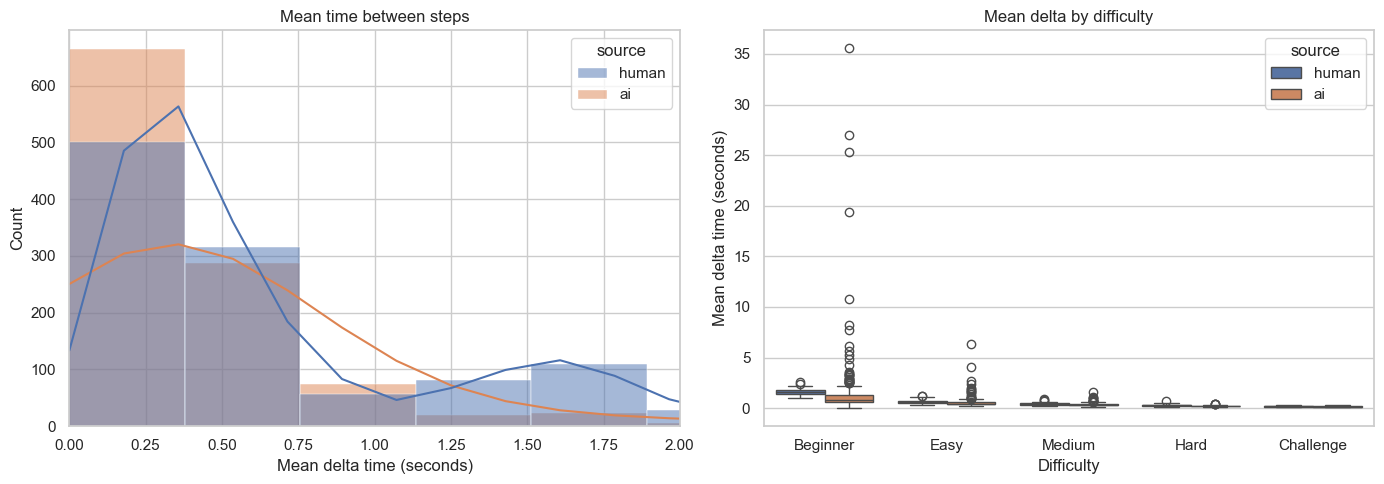

Timing statistics by source:


,mean_delta,std_delta,min_delta
source,,,
ai,0.608,0.707,0.131
human,0.636,0.326,0.321


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x='mean_delta', hue='source', kde=True, ax=axes[0])
axes[0].set_title('Mean time between steps')
axes[0].set_xlabel('Mean delta time (seconds)')
axes[0].set_xlim(0, 2)

sns.boxplot(data=df, x='difficulty', y='mean_delta', hue='source', ax=axes[1])
axes[1].set_title('Mean delta by difficulty')
axes[1].set_xlabel('Difficulty')
axes[1].set_ylabel('Mean delta time (seconds)')

plt.tight_layout()
plt.show()

print("Timing statistics by source:")
df.groupby('source')[['mean_delta', 'std_delta', 'min_delta']].mean().round(3)

### 8. Summary statistics

In [38]:
human_df = df[df['source'] == 'human']
ai_df = df[df['source'] == 'ai']

summary_df = pd.DataFrame({
    'Metric': [
        'Total charts',
        'Unique songs', 
        'Total steps',
        'Mean steps per chart',
        'Mean steps/second',
        'Mean unique patterns',
        'Single arrow ratio',
        'Jump ratio',
        'Hold ratio',
    ],
    'Human': [
        len(human_df),
        human_df['song_name'].nunique(),
        human_df['num_steps'].sum(),
        round(human_df['num_steps'].mean(), 2),
        round(human_df['steps_per_second'].mean(), 2),
        round(human_df['unique_patterns'].mean(), 2),
        round(human_df['single_arrow_ratio'].mean(), 3),
        round(human_df['jump_ratio'].mean(), 3),
        round(human_df['hold_ratio'].mean(), 3),
    ],
    'AI': [
        len(ai_df),
        ai_df['song_name'].nunique(),
        ai_df['num_steps'].sum(),
        round(ai_df['num_steps'].mean(), 2),
        round(ai_df['steps_per_second'].mean(), 2),
        round(ai_df['unique_patterns'].mean(), 2),
        round(ai_df['single_arrow_ratio'].mean(), 3),
        round(ai_df['jump_ratio'].mean(), 3),
        round(ai_df['hold_ratio'].mean(), 3),
    ]
})
display(summary_df.set_index('Metric'))

,Human,AI
Metric,,
Total charts,1094.000,1109.000
Unique songs,222.000,222.000
Total steps,347663.000,454787.000
Mean steps per chart,317.790,410.090
Mean steps/second,2.800,3.500
Mean unique patterns,18.940,24.180
Single arrow ratio,0.858,0.867
Jump ratio,0.062,0.046
Hold ratio,0.044,0.052
